# PDF Corpus EDA & Chunking — RAG / NLP Track (Milestone 2)

This notebook covers the EDA + preprocessing pipeline for the PDF corpus used in the MuRIL-based RAG
system: UP government scheme circulars + agricultural advisories across **4 source folders**.

**Pipeline Structure (ends at the chunk artifact — embedding/indexing is Milestone 3):**
1. **Configuration & Inventory**: Folder paths, SHA-256 integrity hashes, page counts
2. **Text Extraction**: Structure-aware native extraction (`pymupdf4llm` → Markdown tables & headings) + page-level OCR fallback (`pytesseract`, `eng+hin`) + legacy-font (mojibake) detection
3. **Corpus-Level EDA & Visualizations**: Page/word count distributions, missing extractions, bilingual language detection (`en`/`hi`/`mixed`), Markdown-aware garbage ratio, publication year freshness, and functional categorization
4. **Terminology Harmonization**: Standardizing crop names (`paddy`→`rice`), district bifurcations (`faizabad`→`ayodhya`), and consolidating into a single canonical corpus
5. **Integrity & Version Tracking**: SHA-256 checksums and audit manifests
6. **Structure-Aware, Token-Budgeted Chunking**: Two-stage splitting (`MarkdownHeaderTextSplitter` + table-preserving token-budget `RecursiveCharacterTextSplitter`), sized in MuRIL tokens, with section/page provenance metadata → final artifact **`pdf_chunks_final.jsonl`**

> **Deferred to Milestone 3** (separate notebook): MuRIL embedding generation, Qdrant/FAISS vector indexing, retrieval function + tool spec, and retrieval-quality evaluation (Recall@5, MRR, RAGAS) — including the empirical chunk-size/overlap validation described in Section 6.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive/DS_AI_RAG_pdfs/

Other_docs  PPQS_Advisories  Schemes  UP_ACP_PDFs


In [3]:
!cp -r "/content/drive/MyDrive/DS_AI_RAG_pdfs/" /content/

In [4]:
!apt-get update -qq
# poppler-utils -> pdf2image page rendering; tesseract-ocr + hin pack -> bilingual OCR.
# (pytesseract only wraps the OS binary -- without these two apt packages the OCR
# fallback silently degrades to "ocr_unavailable".)
!apt-get install -y poppler-utils tesseract-ocr tesseract-ocr-hin

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following additional packages will be installed:
  libpoppler-dev libpoppler-private-dev libpoppler118
Recommended packages:
  poppler-data
The following NEW packages will be installed:
  poppler-utils tesseract-ocr-hin
The following packages will be upgraded:
  libpoppler-dev libpoppler-private-dev libpoppler118
3 upgraded, 2 newly installed, 0 to remove and 142 not upgraded.
Need to get 2,383 kB of archives.
After this operation, 1,835 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libpoppler-private-dev amd64 22.02.0-2ubuntu0.13 [198 kB]
Get:2 http://archive.ubuntu.com/ubuntu ja

In [5]:
# Install dependencies (uncomment if running fresh)
!pip install PyMuPDF pytesseract pdf2image langdetect pandas matplotlib seaborn tqdm --break-system-packages
# Note: pytesseract also needs the `tesseract-ocr` binary + `tesseract-ocr-hin` (Hindi) language pack installed at the OS level.
# Note: pdf2image needs `poppler-utils` installed at the OS level.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 21.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 67.1 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=9c91c2fc37eeb515d77a66b70b8b74bf1ab94d2508cfe2b2b8b52302c4ee8f42
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [6]:
import os
import re
import glob
import hashlib
import warnings
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import fitz  # PyMuPDF, used as a fallback / for quick metadata

try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 0
    LANGDETECT_AVAILABLE = True
except ImportError:
    LANGDETECT_AVAILABLE = False

try:
    import pytesseract
    from pdf2image import convert_from_path
    OCR_AVAILABLE = True
except ImportError:
    OCR_AVAILABLE = False

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")


## 1. Configuration

Point each key at one of your 4 source folders. The folder name becomes the `source` label used throughout the EDA (e.g. to compare corpora by origin).

In [7]:
FOLDER_PATHS = {
    "other_docs":        "/content/DS_AI_RAG_pdfs/Other_docs",
    "ppqs_advisories":     "/content/DS_AI_RAG_pdfs/PPQS_Advisories",
    "schemes":"/content/DS_AI_RAG_pdfs/Schemes",
    "up_acp":"/content/DS_AI_RAG_pdfs/UP_ACP_PDFs"
}

# Where extracted text + outputs will be saved
OUTPUT_DIR = "./pdf_eda_outputs"
TEXT_DIR = os.path.join(OUTPUT_DIR, "extracted_text")
os.makedirs(TEXT_DIR, exist_ok=True)

# Per-document OCR page budget (Colab safety valve). Hitting the cap is
# recorded in `quality_flag` as `ocr_page_cap_hit` -- truncation is never silent.
MAX_OCR_PAGES = 60
# 300 DPI markedly improves Tesseract accuracy on Devanagari glyphs vs 200.
OCR_DPI = 300

## 2. Build Document Inventory

Walk each folder, collect filename, size, page count, and a content-hash (for later duplicate detection).

In [8]:
def file_hash(path, block_size=65536):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(block_size), b""):
            h.update(block)
    return h.hexdigest()

def get_page_count(path):
    try:
        with fitz.open(path) as doc:
            return doc.page_count
    except Exception:
        return None

records = []
for source, folder in FOLDER_PATHS.items():
    if not os.path.isdir(folder):
        print(f"[WARN] Folder not found, skipping: {folder}")
        continue
    pdf_files = glob.glob(os.path.join(folder, "**", "*.pdf"), recursive=True)
    for path in pdf_files:
        records.append({
            "source": source,
            "filename": os.path.basename(path),
            "filepath": path,
            "size_kb": round(os.path.getsize(path) / 1024, 1),
            "page_count": get_page_count(path),
            "file_hash": file_hash(path),
        })

inventory_df = pd.DataFrame(records)
print(f"Total PDFs found: {len(inventory_df)}")
inventory_df.head()


Total PDFs found: 187


,source,filename,filepath,size_kb,page_count,file_hash
0,other_docs,ICAR-Advisory-WHEAT-April-1-152026.pdf,/content/DS_AI_RAG_pdfs/Other_docs/ICAR-Adviso...,340.7,1,72bce060c89fea887b71c8a6d76b05d666bc1a7541d078...
1,other_docs,Integrated pest management.pdf,/content/DS_AI_RAG_pdfs/Other_docs/Integrated ...,431.4,3,5a4af6edbf4615715d55a256f29c66514997e269d545c8...
2,other_docs,ICAR-Advisory-FOR-SOWING-March-16-312026.pdf,/content/DS_AI_RAG_pdfs/Other_docs/ICAR-Adviso...,530.3,2,226bd391ee98477bad05aeda38752b8bee812a2ccf1a99...
3,other_docs,pop_for_management_of_paddy_blast.pdf,/content/DS_AI_RAG_pdfs/Other_docs/pop_for_man...,141.6,5,edeb0d1e394b36a23be7dcf7dcd9e62e2d35e74b6a42f3...
4,other_docs,Rice-based-cropping-systems.pdf,/content/DS_AI_RAG_pdfs/Other_docs/Rice-based-...,171.1,4,085da2ca25b882a0484a2566757cfc89bacad07e27b51b...


In [9]:
# Exact duplicate check via file hash (catches identical re-uploads across folders)
dupe_hashes = inventory_df["file_hash"].value_counts()
dupe_hashes = dupe_hashes[dupe_hashes > 1]
print(f"Exact-duplicate files (by content hash): {dupe_hashes.sum() - len(dupe_hashes)} redundant copies across {len(dupe_hashes)} groups")

inventory_df["is_exact_duplicate"] = inventory_df["file_hash"].isin(dupe_hashes.index)
inventory_df[inventory_df["is_exact_duplicate"]].sort_values("file_hash")


Exact-duplicate files (by content hash): 2 redundant copies across 2 groups


,source,filename,filepath,size_kb,page_count,file_hash,is_exact_duplicate
34,ppqs_advisories,Advisory on incidence of Fall Army Worm (FAW) ...,/content/DS_AI_RAG_pdfs/PPQS_Advisories/Adviso...,1461.9,2,2f43ff3ca3dc668edd9f78aaa8dd76d944894ade72bbbd...,True
57,ppqs_advisories,Advisory on incidence of Fall Army Worm (FAW) ...,/content/DS_AI_RAG_pdfs/PPQS_Advisories/Adviso...,1461.9,2,2f43ff3ca3dc668edd9f78aaa8dd76d944894ade72bbbd...,True
135,up_acp,FIROZABAD.pdf,/content/DS_AI_RAG_pdfs/UP_ACP_PDFs/FIROZABAD.pdf,1040.0,28,e6813a32c3f1460c62edb889717932d7b6ad65754fe1de...,True
175,up_acp,FAIZABAD.pdf,/content/DS_AI_RAG_pdfs/UP_ACP_PDFs/FAIZABAD.pdf,1040.0,28,e6813a32c3f1460c62edb889717932d7b6ad65754fe1de...,True


In [10]:
# Inspect the duplicate groups properly before deciding what to remove
dupe_groups = inventory_df[inventory_df["is_exact_duplicate"]].sort_values("file_hash")

for h, group in dupe_groups.groupby("file_hash"):
    print(f"\nHash: {h}  ({len(group)} files, size: {group['size_kb'].iloc[0]} KB)")
    print(group[["source", "filename", "size_kb"]].to_string(index=False))


Hash: 2f43ff3ca3dc668edd9f78aaa8dd76d944894ade72bbbde6931225203723e49c  (2 files, size: 1461.9 KB)
         source                                                                                             filename  size_kb
ppqs_advisories                     Advisory on incidence of Fall Army Worm (FAW) spodoptera frugiperda on Maize.pdf   1461.9
ppqs_advisories Advisory on incidence of Fall Army Worm (FAW) Spodoptera frugiperda on Maize in Himachal Pradesh.pdf   1461.9

Hash: e6813a32c3f1460c62edb889717932d7b6ad65754fe1deecad42eca2d697535e  (2 files, size: 1040.0 KB)
source      filename  size_kb
up_acp FIROZABAD.pdf   1040.0
up_acp  FAIZABAD.pdf   1040.0


## 3. Text Extraction (Structure-Aware + Page-Level OCR Fallback)

**Production extraction pipeline (per document):**

1. **Primary — `pymupdf4llm.to_markdown(page_chunks=True)`**: converts each *page* to structured Markdown (tables, `#`-heading hierarchy, lists, reading order across multi-column layouts). Per-page output lets every page be tagged with a `<<pg_N>>` marker, so downstream chunks carry **page-level provenance for citations**.
2. **Sub-fallback — plain `fitz` page text** if `pymupdf4llm` crashes on a document (recorded as `extraction_detail = "fitz_fallback"`, so structure-less docs stay identifiable).
3. **Page-level OCR (`pytesseract`, `eng+hin`)**: only pages whose native text is near-empty are rendered and OCR'd → `extraction_method = "hybrid"`. Fully scanned documents go through full-document OCR → `"ocr"`.
4. **Legacy-font (mojibake) detection**: UP government PDFs are frequently typeset in non-Unicode Hindi fonts (Kruti Dev / Chanakya) whose native "text" extracts as vowel-less Latin gibberish (`Ñíke gks rks`) that character-class garbage checks score as clean English. Documents whose Latin tokens are > 25 % vowel-less are re-routed to OCR; the OCR text is kept only if it recovers substantially more Devanagari. Outcomes are recorded in `quality_flag`.
5. **Running header/footer removal**: lines repeating (digits normalised) on ≥ 60 % of a document's pages are stripped before saving — prevents boilerplate from 74 near-identical ACP templates flooding retrieval. Table rows are never touched.

**Per-document audit columns:** `extraction_method` (`native` / `hybrid` / `ocr` / `failed`), `extraction_detail`, `quality_flag`, `n_pages_ocr`, `boilerplate_lines_removed`, `chars_per_page`.

> **Compute note (Colab free tier):** Tesseract OCR is CPU-only, but only the ~14 scanned docs need it — a few minutes total. The T4 **GPU** is spent where it actually pays off: the embedding stage in Section 7 (`sentence-transformers` auto-detects CUDA).

In [11]:
# Install pymupdf4llm for production-level structure-aware PDF extraction
# It builds on PyMuPDF (fitz) and outputs clean Markdown with tables, headings, etc.
!pip install pymupdf4llm --break-system-packages -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.7/164.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 52.9 MB/s eta 0:00:00


In [12]:
import pymupdf4llm

# ---------------------------------------------------------------------------
# Production text extraction — structure-aware Markdown + page-level OCR fallback
#
#   1. Primary   : pymupdf4llm.to_markdown(page_chunks=True) -> per-PAGE Markdown
#                  (tables, heading hierarchy, lists, multi-column reading order)
#   2. Fallback  : plain fitz per-page text if pymupdf4llm crashes on a doc
#   3. Page OCR  : only near-empty (image-only) pages are rendered & OCR'd
#                  (eng+hin) -> extraction_method = "hybrid"
#   4. Full OCR  : fully-scanned docs, or docs whose native text is legacy-font
#                  mojibake (Kruti Dev / Chanakya PDFs extract as vowel-less
#                  Latin gibberish that character-class garbage checks miss)
#
# Every page is tagged `<<pg_N>>` so downstream chunks carry page provenance.
# Running headers/footers are stripped. All decisions land in audit columns —
# nothing is dropped or truncated silently.
# ---------------------------------------------------------------------------

PAGE_MARKER_FMT = "<<pg_{}>>"
PAGE_MARKER_RE  = re.compile(r"<<pg_(\d+)>>")

MIN_CHARS_PER_PAGE = 50    # native page below this = image-only -> OCR that page
SUSPECT_VOWELLESS  = 0.25  # >25% vowel-less Latin tokens = mojibake suspect


def count_content_words(text):
    """Count true alphanumeric content words (Latin + Devanagari), ignoring Markdown punctuation tokens."""
    return len(re.findall(r"[a-zA-Z0-9\u0900-\u097F]+", text))

def is_near_empty(text, min_chars=50):
    return len(text.strip()) < min_chars

def devanagari_chars(text):
    return len(re.findall(r"[\u0900-\u097F]", text))

def vowelless_latin_ratio(text, sample_chars=8000):
    """Share of vowel-less Latin tokens. Legacy non-Unicode Hindi fonts extract
    as Latin gibberish ('Ñíke gks rks') that ordinary garbage-ratio checks
    score as clean English; an abnormal vowel-less share exposes it."""
    tokens = re.findall(r"[A-Za-z]{2,}", text[:sample_chars])
    if len(tokens) < 30:
        return 0.0
    vowelless = sum(1 for t in tokens if not re.search(r"[aeiouAEIOU]", t))
    return vowelless / len(tokens)

def is_suspect_encoding(text):
    return (vowelless_latin_ratio(text) > SUSPECT_VOWELLESS
            and devanagari_chars(text) < 0.05 * max(len(text), 1))


def extract_native_pages(path):
    """Structure-aware per-page extraction. Returns (list_of_page_texts, detail)."""
    try:
        page_dicts = pymupdf4llm.to_markdown(path, page_chunks=True, show_progress=False)
        pages = [(p["text"] if isinstance(p, dict) else str(p)) or "" for p in page_dicts]
        if pages:
            return pages, "pymupdf4llm"
    except Exception:
        pass
    try:  # structure-less sub-fallback, identifiable via extraction_detail
        with fitz.open(path) as doc:
            return [pg.get_text() or "" for pg in doc], "fitz_fallback"
    except Exception:
        return None, "native_failed"


def ocr_single_page(path, page_no, dpi=OCR_DPI):
    """Render & OCR one page (1-based). Page-at-a-time keeps Colab RAM flat."""
    try:
        imgs = convert_from_path(path, dpi=dpi, first_page=page_no, last_page=page_no)
        if imgs:
            return pytesseract.image_to_string(imgs[0], lang="eng+hin")
    except Exception:
        pass
    return ""


def strip_repeated_lines(pages, min_pages=4, threshold=0.6, edge=3):
    """Remove running headers/footers: lines that repeat (digits normalised) on
    >= threshold of pages AND sit within the first/last `edge` lines of a page.

    The positional guard matters -- without it, body content that happens to
    differ only by a number (list items, per-page data lines) is deleted as
    boilerplate. Table rows (`|`) are never touched.
    Returns (cleaned_pages, n_lines_removed)."""
    if len(pages) < min_pages:
        return pages, 0
    norm = lambda l: re.sub(r"\d+", "#", l.strip())
    eligible = lambda l, idx, total: (
        len(norm(l)) >= 4
        and not l.lstrip().startswith("|")
        and (idx < edge or idx >= total - edge)   # header/footer zone only
    )

    line_pages = defaultdict(set)
    for i, p in enumerate(pages):
        lines = p.splitlines()
        for j, l in enumerate(lines):
            if eligible(l, j, len(lines)):
                line_pages[norm(l)].add(i)
    repeated = {n for n, on in line_pages.items() if len(on) >= threshold * len(pages)}
    if not repeated:
        return pages, 0

    removed, out = 0, []
    for p in pages:
        lines = p.splitlines()
        kept = []
        for j, l in enumerate(lines):
            if eligible(l, j, len(lines)) and norm(l) in repeated:
                removed += 1
            else:
                kept.append(l)
        out.append("\n".join(kept))
    return out, removed


extraction_rows = []
for _, row in tqdm(inventory_df.iterrows(), total=len(inventory_df)):
    path = row["filepath"]
    n_pages = int(row["page_count"]) if pd.notna(row["page_count"]) else (get_page_count(path) or 0)

    pages, detail = extract_native_pages(path)
    pages = pages if pages is not None else []
    page_methods = ["native"] * len(pages)
    quality_flag = ""
    n_ocr_pages, ocr_truncated = 0, False

    # --- Page-level OCR: only the near-empty (image-only) pages -------------
    if OCR_AVAILABLE and pages:
        for i, ptext in enumerate(pages):
            if len(ptext.strip()) < MIN_CHARS_PER_PAGE:
                if n_ocr_pages >= MAX_OCR_PAGES:
                    ocr_truncated = True
                    break
                otext = ocr_single_page(path, i + 1)
                n_ocr_pages += 1
                if len(otext.strip()) >= MIN_CHARS_PER_PAGE:
                    pages[i] = otext
                    page_methods[i] = "ocr"

    # --- Full-document OCR: fully scanned, or legacy-font mojibake ----------
    native_text = "\n".join(pages)
    suspect = bool(pages) and is_suspect_encoding(native_text)
    if OCR_AVAILABLE and (is_near_empty(native_text) or suspect):
        limit = min(n_pages, MAX_OCR_PAGES) if n_pages else MAX_OCR_PAGES
        ocr_pgs = [ocr_single_page(path, p + 1) for p in range(limit)]
        ocr_text = "\n".join(ocr_pgs)
        # keep OCR only if it beats native: native was empty, or OCR recovers real Devanagari
        take_ocr = is_near_empty(native_text) or \
                   devanagari_chars(ocr_text) > 2 * devanagari_chars(native_text) + 50
        if take_ocr and not is_near_empty(ocr_text):
            pages, page_methods = ocr_pgs, ["ocr"] * len(ocr_pgs)
            n_ocr_pages, detail = len(ocr_pgs), "ocr_full"
            ocr_truncated = n_pages > limit
            if suspect:
                quality_flag = "legacy_font_resolved_by_ocr"
        elif suspect:
            quality_flag = "suspect_encoding_unresolved"
    elif suspect:
        quality_flag = "suspect_encoding_unresolved"

    # --- Boilerplate removal + page-tagged assembly --------------------------
    pages, removed_lines = strip_repeated_lines(pages) if pages else ([], 0)
    full_text = "\n".join(
        f"{PAGE_MARKER_FMT.format(i + 1)}\n\n{p.strip()}\n" for i, p in enumerate(pages)
    )
    content = PAGE_MARKER_RE.sub(" ", full_text)  # marker-free view for stats

    if is_near_empty(content):
        method = "failed"
    elif page_methods and all(m == "ocr" for m in page_methods):
        method = "ocr"
    elif "ocr" in page_methods:
        method = "hybrid"
    else:
        method = "native"

    if ocr_truncated:
        quality_flag = (quality_flag + ";" if quality_flag else "") + "ocr_page_cap_hit"

    out_dir = os.path.join(TEXT_DIR, row["source"])
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, os.path.splitext(row["filename"])[0] + ".txt")
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(full_text)

    extraction_rows.append({
        "filepath": path,
        "extraction_method": method,
        "extraction_detail": detail,
        "quality_flag": quality_flag,
        "n_pages_ocr": n_ocr_pages,
        "boilerplate_lines_removed": removed_lines,
        "char_count": len(content),
        "word_count": count_content_words(content),
        "chars_per_page": round(len(content) / max(len(pages), 1), 1),
        "text_output_path": out_path,
    })

extraction_df = pd.DataFrame(extraction_rows)
inventory_df = inventory_df.merge(extraction_df, on="filepath", how="left")

print("Extraction method breakdown:")
print(inventory_df["extraction_method"].value_counts())
print("\nExtraction detail breakdown:")
print(inventory_df["extraction_detail"].value_counts())
flagged = inventory_df[inventory_df["quality_flag"] != ""]
print(f"\nQuality-flagged documents: {len(flagged)}")
if len(flagged):
    print(flagged[["source", "filename", "quality_flag", "n_pages_ocr"]].to_string(index=False))
inventory_df.head()

  0%|          | 0/187 [00:00<?, ?it/s]

=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=0/1.



  1%|          | 1/187 [00:07<22:18,  7.20s/it]

=== Document parser messages ===
                                                            Using Tesseract for OCR processing.
OCR on page.number=0/1.
OCR on page.number=1/2.
OCR on page.number=2/3.



  1%|          | 2/187 [00:45<1:19:22, 25.74s/it]

...

 99%|█████████▉| 186/187 [41:17<00:18, 18.49s/it]

=== Document parser messages ===
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

100%|██████████| 187/187 [41:37<00:00, 13.35s/it]

Extraction method breakdown:
extraction_method
native    131
hybrid     55
ocr         1
Name: count, dtype: int64

Extraction detail breakdown:
extraction_detail
pymupdf4llm    186
ocr_full         1
Name: count, dtype: int64

Quality-flagged documents: 1
         source                                                                            filename                quality_flag  n_pages_ocr
ppqs_advisories Package of Practice (POP) for the management of Fall Army Worm (FAW) in Sorghum.pdf legacy_font_resolved_by_ocr            3


,source,filename,filepath,size_kb,page_count,file_hash,is_exact_duplicate,extraction_method,extraction_detail,quality_flag,n_pages_ocr,boilerplate_lines_removed,char_count,word_count,chars_per_page,text_output_path
0,other_docs,ICAR-Advisory-WHEAT-April-1-152026.pdf,/content/DS_AI_RAG_pdfs/Other_docs/ICAR-Adviso...,340.7,1,72bce060c89fea887b71c8a6d76b05d666bc1a7541d078...,False,native,pymupdf4llm,,0,0,2163,378,2163.0,./pdf_eda_outputs/extracted_text/other_docs/IC...
1,other_docs,Integrated pest management.pdf,/content/DS_AI_RAG_pdfs/Other_docs/Integrated ...,431.4,3,5a4af6edbf4615715d55a256f29c66514997e269d545c8...,False,native,pymupdf4llm,,0,0,5034,1185,1678.0,./pdf_eda_outputs/extracted_text/other_docs/In...
2,other_docs,ICAR-Advisory-FOR-SOWING-March-16-312026.pdf,/content/DS_AI_RAG_pdfs/Other_docs/ICAR-Adviso...,530.3,2,226bd391ee98477bad05aeda38752b8bee812a2ccf1a99...,False,native,pymupdf4llm,,0,0,3002,499,1501.0,./pdf_eda_outputs/extracted_text/other_docs/IC...
3,other_docs,pop_for_management_of_paddy_blast.pdf,/content/DS_AI_RAG_pdfs/Other_docs/pop_for_man...,141.6,5,edeb0d1e394b36a23be7dcf7dcd9e62e2d35e74b6a42f3...,False,native,pymupdf4llm,,0,0,7048,1153,1409.6,./pdf_eda_outputs/extracted_text/other_docs/po...
4,other_docs,Rice-based-cropping-systems.pdf,/content/DS_AI_RAG_pdfs/Other_docs/Rice-based-...,171.1,4,085da2ca25b882a0484a2566757cfc89bacad07e27b51b...,False,native,pymupdf4llm,,0,0,15030,2335,3757.5,./pdf_eda_outputs/extracted_text/other_docs/Ri...


## 4. Corpus-Level EDA

### 4.1 Summary statistics

,num_docs,total_pages,avg_pages,avg_words,ocr_docs,failed_docs
source,,,,,,
other_docs,13,200,15.4,4608.3,0,0
ppqs_advisories,89,386,4.3,1273.9,1,0
schemes,11,359,32.6,9396.6,0,0
up_acp,74,1805,24.4,5557.3,0,0


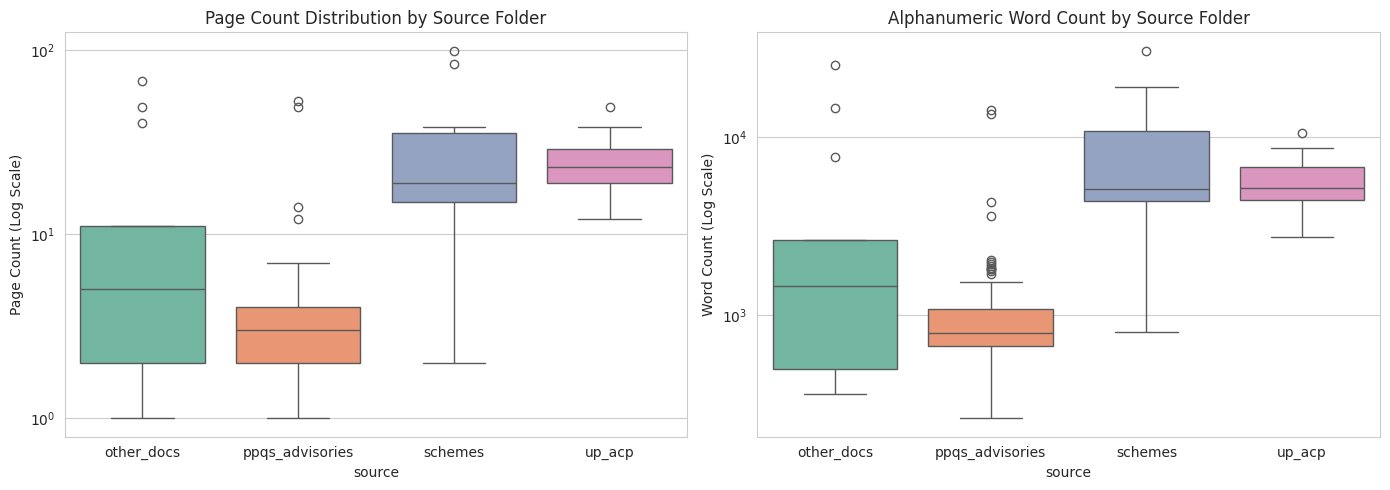

In [13]:
summary = inventory_df.groupby("source").agg(
    num_docs=("filename", "count"),
    total_pages=("page_count", "sum"),
    avg_pages=("page_count", "mean"),
    avg_words=("word_count", "mean"),
    ocr_docs=("extraction_method", lambda x: (x == "ocr").sum()),
    failed_docs=("extraction_method", lambda x: (x == "failed").sum()),
).round(1)
display(summary)

# Visualization: Page & Word Count Distributions by Source Folder
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=inventory_df, x="source", y="page_count", ax=axes[0], palette="Set2")
axes[0].set_title("Page Count Distribution by Source Folder")
axes[0].set_yscale("log")
axes[0].set_ylabel("Page Count (Log Scale)")

sns.boxplot(data=inventory_df, x="source", y="word_count", ax=axes[1], palette="Set2")
axes[1].set_title("Alphanumeric Word Count by Source Folder")
axes[1].set_yscale("log")
axes[1].set_ylabel("Word Count (Log Scale)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_page_word_distribution.png"), dpi=150)
plt.show()


### 4.2 Missing / near-empty extraction analysis

Documents with failed/near-empty extraction: 0 / 187


,source,filename,page_count,char_count


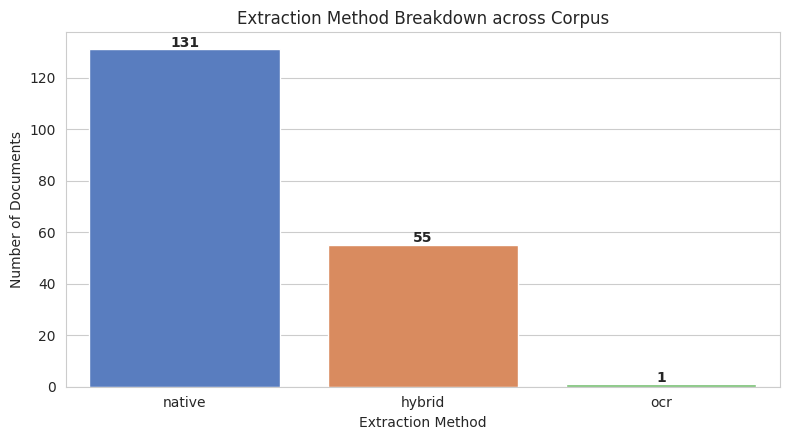

In [14]:
failed_df = inventory_df[inventory_df["extraction_method"] == "failed"]
print(f"Documents with failed/near-empty extraction: {len(failed_df)} / {len(inventory_df)}")
display(failed_df[["source", "filename", "page_count", "char_count"]])

# Visualization: Extraction Method Breakdown
plt.figure(figsize=(8, 4.5))
method_counts = inventory_df["extraction_method"].value_counts()
sns.barplot(x=method_counts.index, y=method_counts.values, palette="muted")
plt.title("Extraction Method Breakdown across Corpus")
plt.xlabel("Extraction Method")
plt.ylabel("Number of Documents")
for i, v in enumerate(method_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_extraction_methods.png"), dpi=150)
plt.show()


In [15]:
# Final exclusion list -- these are permanently dropped from the RAG corpus
excluded_df = inventory_df[inventory_df["extraction_method"] == "excluded_unreadable"].copy()

print(f"Final excluded (unreadable) documents: {len(excluded_df)}")
excluded_df[["source", "filename", "page_count", "size_kb"]]

# Save the exclusion list separately -- this is your audit trail for Section 11 (Challenges)
excluded_df.to_csv(os.path.join(OUTPUT_DIR, "excluded_unreadable_docs.csv"), index=False)

# Clean corpus = everything except excluded docs
clean_inventory_df = inventory_df[inventory_df["extraction_method"] != "excluded_unreadable"].copy()
clean_inventory_df.to_csv(os.path.join(OUTPUT_DIR, "pdf_inventory_clean.csv"), index=False)

print(f"\nFinal clean corpus: {len(clean_inventory_df)} / {len(inventory_df)} documents")

Final excluded (unreadable) documents: 0

Final clean corpus: 187 / 187 documents


### 4.3 Duplicate analysis (exact + near-duplicate)

In [16]:
# Exact duplicates already flagged via file_hash above.
# Near-duplicate check on extracted text (e.g. same circular re-uploaded with a different cover page)
from difflib import SequenceMatcher

def text_similarity(a, b, sample_chars=3000):
    return SequenceMatcher(None, a[:sample_chars], b[:sample_chars]).ratio()

texts = {}
for _, row in inventory_df.iterrows():
    if row["extraction_method"] != "failed" and os.path.exists(row["text_output_path"]):
        with open(row["text_output_path"], encoding="utf-8") as f:
            texts[row["filepath"]] = f.read()

near_dupes = []
paths = list(texts.keys())
for i in range(len(paths)):
    for j in range(i + 1, len(paths)):
        sim = text_similarity(texts[paths[i]], texts[paths[j]])
        if sim > 0.9:
            near_dupes.append((paths[i], paths[j], round(sim, 3)))

near_dupes_df = pd.DataFrame(near_dupes, columns=["file_a", "file_b", "similarity"])
print(f"Near-duplicate pairs found (similarity > 0.90): {len(near_dupes_df)}")
near_dupes_df


Near-duplicate pairs found (similarity > 0.90): 2


,file_a,file_b,similarity
0,/content/DS_AI_RAG_pdfs/PPQS_Advisories/Adviso...,/content/DS_AI_RAG_pdfs/PPQS_Advisories/Adviso...,1.0
1,/content/DS_AI_RAG_pdfs/UP_ACP_PDFs/FIROZABAD.pdf,/content/DS_AI_RAG_pdfs/UP_ACP_PDFs/FAIZABAD.pdf,1.0


In [17]:
# Resolve near-duplicates: keep the file with more words per pair (or native over OCR if tied), drop the other
near_dupes_df["a_filename"] = near_dupes_df["file_a"].apply(lambda p: os.path.basename(p))
near_dupes_df["b_filename"] = near_dupes_df["file_b"].apply(lambda p: os.path.basename(p))
near_dupes_df["a_words"] = near_dupes_df["file_a"].map(inventory_df.set_index("filepath")["word_count"])
near_dupes_df["b_words"] = near_dupes_df["file_b"].map(inventory_df.set_index("filepath")["word_count"])

to_drop = set()
for _, row in near_dupes_df.iterrows():
    a, b = row["file_a"], row["file_b"]
    if a in to_drop or b in to_drop:
        continue  # already resolved via a chained duplicate
    if row["a_words"] >= row["b_words"]:
        to_drop.add(b)
    else:
        to_drop.add(a)

print(f"Files marked for removal as near-duplicates: {len(to_drop)}")

inventory_df["is_near_duplicate_dropped"] = inventory_df["filepath"].isin(to_drop)
near_dupe_dropped_df = inventory_df[inventory_df["is_near_duplicate_dropped"]][["source", "filename", "word_count"]]
print(near_dupe_dropped_df)

# Update clean_inventory_df: remove near-duplicates on top of the earlier unreadable exclusion
clean_inventory_df = clean_inventory_df[~clean_inventory_df["filepath"].isin(to_drop)].copy()

# Save updated audit trail
near_dupe_dropped_df.to_csv(os.path.join(OUTPUT_DIR, "excluded_near_duplicate_docs.csv"), index=False)
clean_inventory_df.to_csv(os.path.join(OUTPUT_DIR, "pdf_inventory_clean.csv"), index=False)

print(f"\nFinal clean corpus after both exclusions: {len(clean_inventory_df)} / {len(inventory_df)} documents")

Files marked for removal as near-duplicates: 2
              source                                           filename  \
57   ppqs_advisories  Advisory on incidence of Fall Army Worm (FAW) ...   
175           up_acp                                       FAIZABAD.pdf   

     word_count  
57          981  
175        4705  

Final clean corpus after both exclusions: 185 / 187 documents


### 4.4 Language distribution

Language distribution breakdown:


,count
detected_language,
en,184
mixed,1


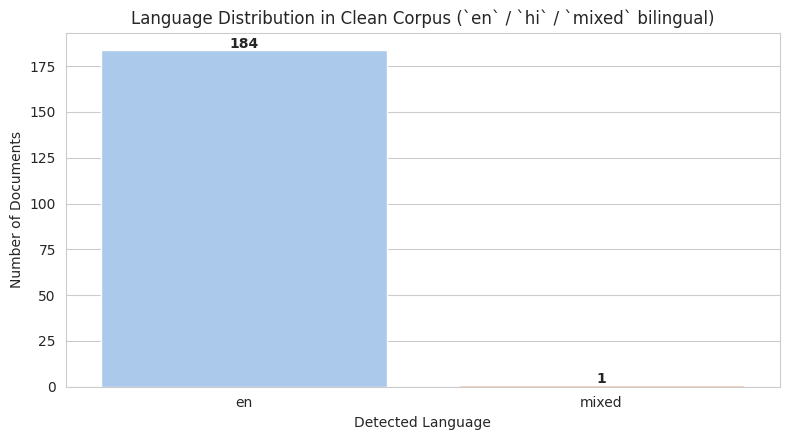

In [18]:
def detect_language(text, sample_chars=4000):
    """Multi-sample bilingual language detection (`en` / `hi` / `mixed`)."""
    # Sample evenly from start, middle, and end if text is long
    if len(text) > sample_chars:
        part = sample_chars // 3
        mid = len(text) // 2
        sample = (text[:part] + " " + text[mid - part//2 : mid + part//2] + " " + text[-part:]).strip()
    else:
        sample = text.strip()
    if not sample:
        return "unknown"

    # Count Devanagari vs Latin characters
    devanagari = len(re.findall(r"[\u0900-\u097F]", sample))
    latin = len(re.findall(r"[a-zA-Z]", sample))
    total_alpha = max(devanagari + latin, 1)

    dev_ratio = devanagari / total_alpha
    lat_ratio = latin / total_alpha

    # If both Hindi and English make up significant proportions, tag as bilingual/mixed
    if dev_ratio > 0.15 and lat_ratio > 0.15:
        return "mixed"
    if dev_ratio > 0.3:
        return "hi"

    if LANGDETECT_AVAILABLE:
        try:
            return detect(sample)
        except Exception:
            pass
    return "en"

languages = []
for _, row in clean_inventory_df.iterrows():
    if os.path.exists(row["text_output_path"]):
        with open(row["text_output_path"], encoding="utf-8") as f:
            languages.append(detect_language(f.read()))
    else:
        languages.append("unknown")

clean_inventory_df["detected_language"] = languages
print("Language distribution breakdown:")
display(clean_inventory_df["detected_language"].value_counts())

# Visualization: Language Distribution
plt.figure(figsize=(8, 4.5))
lang_counts = clean_inventory_df["detected_language"].value_counts()
sns.barplot(x=lang_counts.index, y=lang_counts.values, palette="pastel")
plt.title("Language Distribution in Clean Corpus (`en` / `hi` / `mixed` bilingual)")
plt.xlabel("Detected Language")
plt.ylabel("Number of Documents")
for i, v in enumerate(lang_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_language_distribution.png"), dpi=150)
plt.show()


### 4.5 Garbage-character / OCR-quality check

High garbage ratio documents (> 0.15 cutoff):


,source,filename,extraction_method,garbage_char_ratio


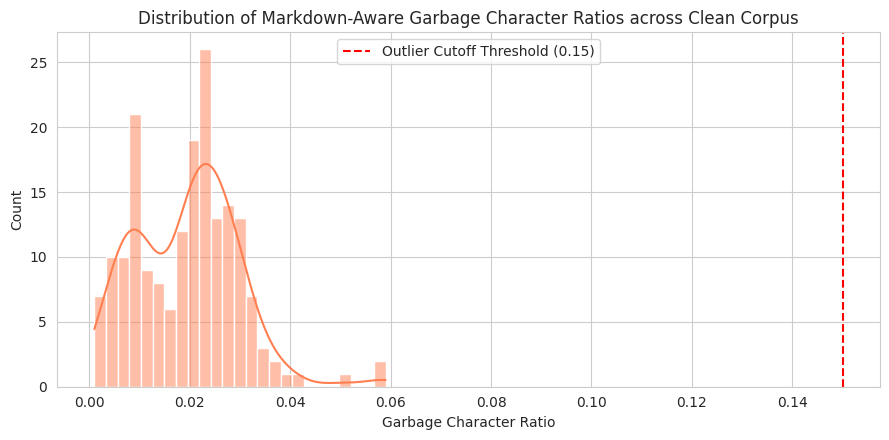

In [19]:
def garbage_ratio(text, sample_chars=3000):
    """Calculate garbage/OCR-noise ratio while preserving Markdown syntax tokens & Indian punctuation."""
    sample = text[:sample_chars]
    if not sample.strip():
        return 1.0
    # Include valid Markdown syntax markers (#, |, *, _, [, ], >, !, `, ~) and Indian symbols (₹, %)
    valid = len(re.findall(r"[a-zA-Z0-9\u0900-\u097F\s.,;:()\-#|*_\[\]>!`~='\/+\%\"₹@$]", sample))
    return round(max(0.0, 1.0 - (valid / len(sample))), 3)

garbage_scores = []
for _, row in clean_inventory_df.iterrows():
    if os.path.exists(row["text_output_path"]):
        with open(row["text_output_path"], encoding="utf-8") as f:
            garbage_scores.append(garbage_ratio(f.read()))
    else:
        garbage_scores.append(None)

clean_inventory_df["garbage_char_ratio"] = garbage_scores
print("High garbage ratio documents (> 0.15 cutoff):")
display(clean_inventory_df[clean_inventory_df["garbage_char_ratio"] > 0.15][["source", "filename", "extraction_method", "garbage_char_ratio"]])

# Visualization: Garbage Ratio Distribution
plt.figure(figsize=(9, 4.5))
sns.histplot(clean_inventory_df["garbage_char_ratio"].dropna(), bins=25, kde=True, color="coral")
plt.axvline(0.15, color="red", linestyle="--", label="Outlier Cutoff Threshold (0.15)")
plt.title("Distribution of Markdown-Aware Garbage Character Ratios across Clean Corpus")
plt.xlabel("Garbage Character Ratio")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_garbage_ratio.png"), dpi=150)
plt.show()


### 4.6 Document date / freshness check (heuristic)

Looks for a 4-digit year in the filename or extracted text to flag potentially outdated scheme documents.

,count
detected_year,
1968.0,1
2014.0,2
2016.0,1
2017.0,2
2018.0,18
2019.0,11
2020.0,7
2021.0,3
2022.0,19


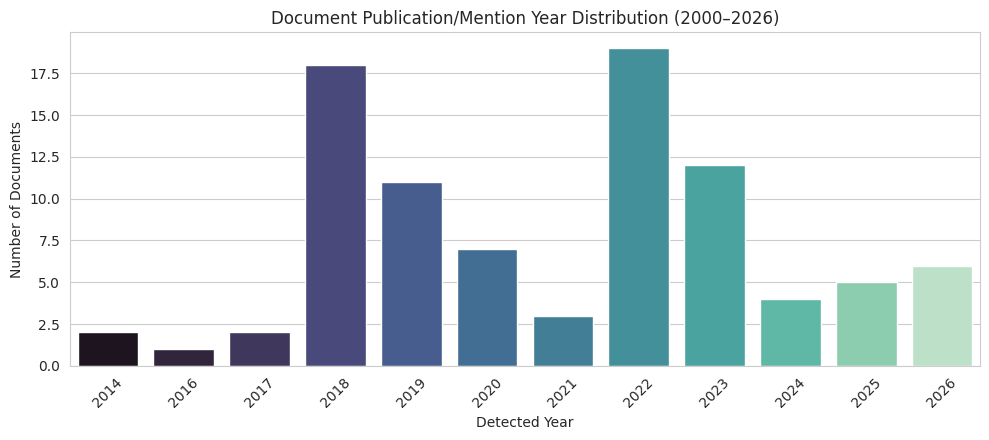

In [20]:
def extract_year(text_or_name):
    all_years = re.findall(r"\b(19\d{2}|20\d{2})\b", text_or_name)
    return max(map(int, all_years)) if all_years else None

detected_years = []
for _, row in clean_inventory_df.iterrows():
    year = extract_year(row["filename"])
    if year is None and os.path.exists(row["text_output_path"]):
        with open(row["text_output_path"], encoding="utf-8") as f:
            year = extract_year(f.read()[:2000])
    detected_years.append(year)

clean_inventory_df["detected_year"] = detected_years
display(clean_inventory_df["detected_year"].value_counts(dropna=False).sort_index())

# Visualization: Document Publication/Mention Year Timeline
plt.figure(figsize=(10, 4.5))
year_data = clean_inventory_df["detected_year"].dropna().astype(int)
year_data = year_data[(year_data >= 2000) & (year_data <= 2026)]  # Plausible range for timeline chart
sns.countplot(x=year_data, palette="mako")
plt.title("Document Publication/Mention Year Distribution (2000–2026)")
plt.xlabel("Detected Year")
plt.ylabel("Number of Documents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_year_distribution.png"), dpi=150)
plt.show()


In [21]:
# Inspect the document(s) flagged with implausible years
implausible = clean_inventory_df[
    (clean_inventory_df["detected_year"] > 2026) | (clean_inventory_df["detected_year"] < 1990)
]
print(f"Documents with implausible years (<1990 or >2026): {len(implausible)}")
display(implausible[["source", "filename", "detected_year"]])

# Check what text triggered the match
for _, row in implausible.iterrows():
    path = row.get("text_output_path")
    if isinstance(path, str) and os.path.exists(path):
        with open(path, encoding="utf-8") as f:
            text = f.read()
        year = int(row["detected_year"]) if pd.notna(row["detected_year"]) else 2027
        match = re.search(rf".{{40}}{year}.{{40}}", text)
        print(f"\n{row['filename']} (detected year {year}):")
        print(match.group() if match else "Year found in filename or outside first 2000 chars")


Documents with implausible years (<1990 or >2026): 2


,source,filename,detected_year
17,ppqs_advisories,"Grow Safe Food - Beware of Counterfeit, Spurio...",1968.0
49,ppqs_advisories,Advisory on incidence of leaf thrips (Scirtoth...,2027.0



Grow Safe Food - Beware of Counterfeit, Spurious, substandard and unregistered_unlicensed pesticides.pdf (detected year 1968):
sr 3ik sisRvr fi-cflRff-</sup> gfrfrqq, 1968 fi :rtfra<sup>(rfi eis{F</sup> 3rqrrq t

Advisory on incidence of leaf thrips (Scirtothrips dorasalis) and invasive thrips (Thrips parvispinus) to major Chilli growing areas.pdf (detected year 2027):
Year found in filename or outside first 2000 chars


# 4.7 Word Frequency Analysis

Top 30 most frequent words (stopwords removed):


,word,count
0,sup,11000
1,water,4969
2,crop,3464
3,rice,3395
4,irrigation,3137
5,area,2106
6,use,2052
7,provide,2036
8,cropping,1996
9,system,1831


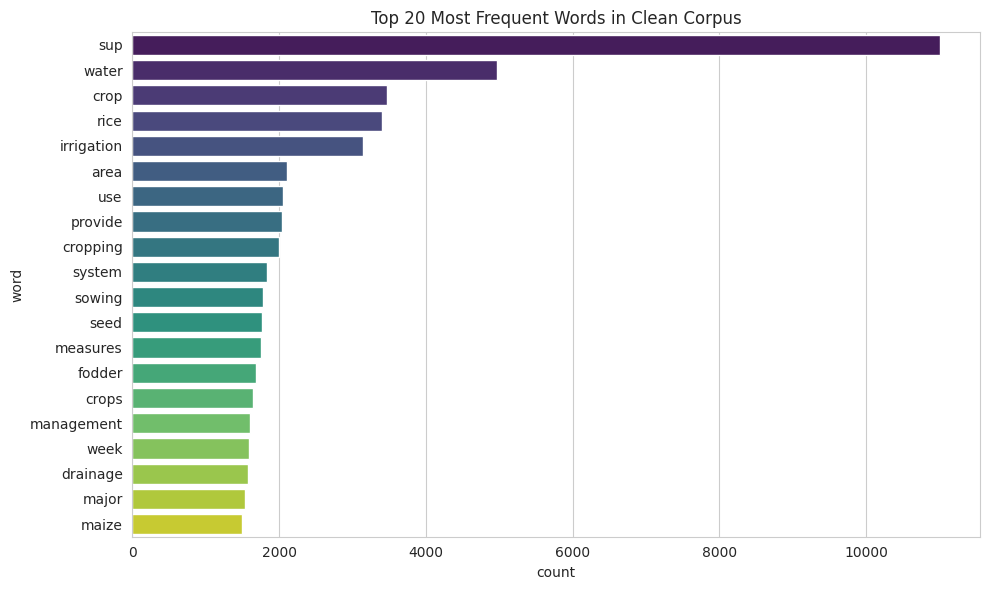

In [22]:
import re
from collections import Counter

ENGLISH_STOPWORDS = set("""
the a an is are was were be been being of to in on for and or with as at by from
this that these those it its it's he she they them his her their we you your i
not no yes will shall can could would should may might must have has had do does did
""".split())

HINDI_STOPWORDS = set("""
और के का की को है हैं था थे थी में से पर एक यह वह इस उस कि जो भी नहीं तो अगर लिए
""".split())

STOPWORDS = ENGLISH_STOPWORDS | HINDI_STOPWORDS

def tokenize(text):
    tokens = re.findall(r"[a-zA-Z\u0900-\u097F]+", text.lower())
    return [t for t in tokens if t not in STOPWORDS and len(t) > 2]

all_tokens = []
for _, row in clean_inventory_df.iterrows():
    if os.path.exists(row["text_output_path"]):
        with open(row["text_output_path"], encoding="utf-8") as f:
            all_tokens.extend(tokenize(f.read()))

word_freq = Counter(all_tokens)
top_words_df = pd.DataFrame(word_freq.most_common(30), columns=["word", "count"])
print("Top 30 most frequent words (stopwords removed):")
display(top_words_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_words_df.head(20), x="count", y="word", palette="viridis")
plt.title("Top 20 Most Frequent Words in Clean Corpus")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "word_frequency.png"), dpi=150)
plt.show()



## 4.8 Document Category Justification ("Why These PDFs")

TA feedback: *"The rationale for selecting the final datasets is not sufficiently justified."*

Each document is tagged with one of four functional categories, matched against the project's
Rice/Wheat/UP scope from Milestone 1. This turns the corpus from an unexplained list of 187
PDFs into a set of documents each justified by an explicit inclusion rule.

**Inclusion criteria (all four must hold for a document to be in-corpus):**
1. Official government / institutional origin (Union or UP State portals, ICAR, RBI, PPQS)
2. Directly relevant to Rice and/or Wheat cultivation, or to a scheme a UP farmer could access
3. Falls into one of the four functional categories below
4. Not a duplicate/superseded version of an already-included document

**Rejected alternatives (and why):**
- General agricultural blogs / web-scraped articles — unverifiable authorship, no authority
- Secondary summaries (e.g. news coverage of a scheme) — risk of inaccuracy vs. primary source
- Non-UP state scheme/advisory documents — out of the project's UP-only scope (Milestone 1)
- Cash-crop-only circulars (e.g. sugarcane-exclusive) — out of the Rice/Wheat scope

In [23]:
def categorize_document(source, filename):
    """Assigns a functional category + one-line rationale per document.
    Folder is the primary signal; filename keywords refine `other_docs` (mixed folder).
    """
    fname_lower = filename.lower()

    if source == "schemes":
        return "scheme_eligibility", "UP/Union scheme document defining farmer eligibility, benefits, or subsidy terms."
    if source == "ppqs_advisories":
        return "crop_advisory", "PPQS pest/disease management advisory — addresses dosage-hallucination risk (Milestone 1)."
    if source == "up_acp":
        return "contingency_plan", "UP district-level Agriculture Contingency Plan — regional planning/advisory content."

    # other_docs is a mixed folder -- classify by filename keywords
    scheme_kw = ["scheme", "guideline", "kisan", "subvention", "yojana", "credit card", "bima"]
    advisory_kw = ["advisory", "blast", "pest", "disease", "cropping", "wheat", "rice", "paddy", "pop_for"]

    if any(kw in fname_lower for kw in scheme_kw):
        return "scheme_eligibility", "Central scheme guideline (matched via filename) — policy/eligibility content."
    if any(kw in fname_lower for kw in advisory_kw):
        return "crop_advisory", "Crop-specific advisory/practice guide (matched via filename)."
    return "policy_guideline", "General agricultural policy/reference document (ICAR magazine, cultivation guide, etc.)."

clean_inventory_df[["doc_category", "category_rationale"]] = clean_inventory_df.apply(
    lambda row: pd.Series(categorize_document(row["source"], row["filename"])), axis=1
)

print("Document category breakdown:")
print(clean_inventory_df["doc_category"].value_counts())
clean_inventory_df[["source", "filename", "doc_category", "category_rationale"]].head(10)

Document category breakdown:
doc_category
crop_advisory         97
contingency_plan      73
scheme_eligibility    11
policy_guideline       4
Name: count, dtype: int64


,source,filename,doc_category,category_rationale
0,other_docs,ICAR-Advisory-WHEAT-April-1-152026.pdf,crop_advisory,Crop-specific advisory/practice guide (matched...
1,other_docs,Integrated pest management.pdf,crop_advisory,Crop-specific advisory/practice guide (matched...
2,other_docs,ICAR-Advisory-FOR-SOWING-March-16-312026.pdf,crop_advisory,Crop-specific advisory/practice guide (matched...
3,other_docs,pop_for_management_of_paddy_blast.pdf,crop_advisory,Crop-specific advisory/practice guide (matched...
4,other_docs,Rice-based-cropping-systems.pdf,crop_advisory,Crop-specific advisory/practice guide (matched...
5,other_docs,EB-52-Wheat-Cultivation-in-India-Pocket-Guide.pdf,crop_advisory,Crop-specific advisory/practice guide (matched...
6,other_docs,CMP_Circulars_29102025_638973560481999250_Rabi...,policy_guideline,General agricultural policy/reference document...
7,other_docs,ICAR-Advisory-WHEAT-April-16-302026.pdf,crop_advisory,Crop-specific advisory/practice guide (matched...
8,other_docs,7-9-Diseases-of-Wheat.pdf,crop_advisory,Crop-specific advisory/practice guide (matched...
9,other_docs,ICAR-Advisory-March-1-152026.pdf,crop_advisory,Crop-specific advisory/practice guide (matched...


Category distribution by source folder (confirms folder-category alignment):


doc_category,contingency_plan,crop_advisory,policy_guideline,scheme_eligibility
source,,,,
other_docs,0,9,4,0
ppqs_advisories,0,88,0,0
schemes,0,0,0,11
up_acp,73,0,0,0


<Figure size 1000x550 with 0 Axes>

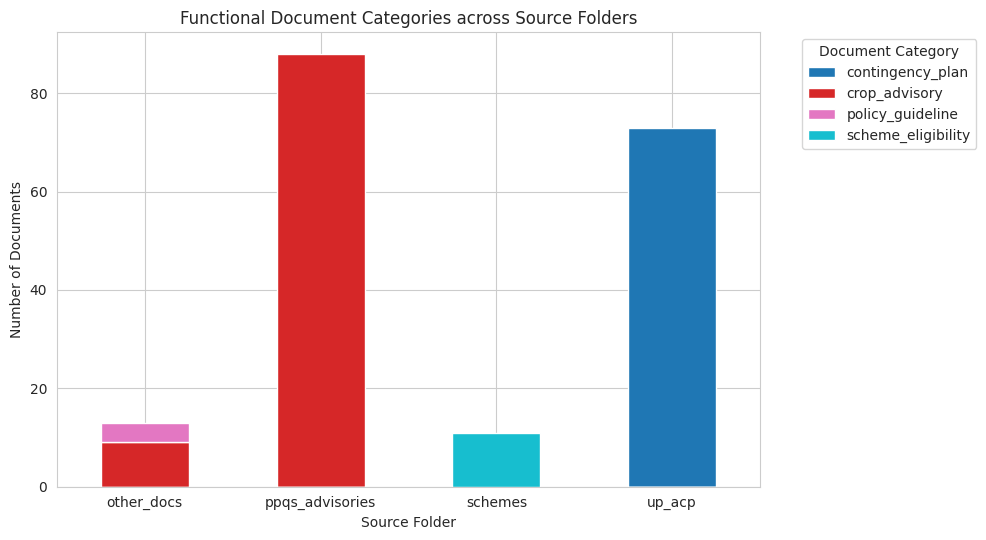

In [24]:
category_by_source = pd.crosstab(clean_inventory_df["source"], clean_inventory_df["doc_category"])
print("Category distribution by source folder (confirms folder-category alignment):")
display(category_by_source)

# Visualization: Document Categories across Source Folders
plt.figure(figsize=(10, 5.5))
category_by_source.plot(kind="bar", stacked=True, colormap="tab10", figsize=(10, 5.5))
plt.title("Functional Document Categories across Source Folders")
plt.xlabel("Source Folder")
plt.ylabel("Number of Documents")
plt.xticks(rotation=0)
plt.legend(title="Document Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_category_by_source.png"), dpi=150)
plt.show()


## 4.9 Terminology Harmonization (Crop / District / Agricultural Terms)

TA feedback: *"There is little discussion of standardizing: crop names, district names, scheme
names, agricultural terminology across different document sources."*

This section builds a **data-driven candidate list** of terminology variants found in the
corpus (e.g. "paddy" vs "rice", old district names vs current ones post-bifurcation), matched
against two reference lists:
- A canonical **crop name list** (aligned with the Yield subsystem's crop vocabulary)
- The official **75-district UP list** (post-1997 bifurcations included, e.g. Ayodhya/Faizabad)

**Nothing is auto-applied.** Every candidate is exported for manual review; only entries a
human confirms are moved into `VALIDATED_ALIASES` and actually applied to the text.

In [25]:
# --- Curated terminology harmonization dictionary (crop names & district bifurcations) ---
# Rationale: semantic (word2vec) and fuzzy-spelling discovery were both tested and found
# unreliable at this corpus size -- word2vec produced near-random similarity scores due to
# insufficient training data, and fuzzy-spelling matched on coincidental character overlap.
# A hand-curated dictionary is the reliable approach at this scale.

VALIDATED_ALIASES = {
    # Crop name variants (Hindi/Hinglish -> canonical English, matching Yield subsystem vocabulary)
    "paddy": "rice", "dhan": "rice", "chawal": "rice",
    "gehun": "wheat", "gehu": "wheat", "kanak": "wheat",
    "makka": "maize", "makai": "maize", "bhutta": "maize",
    "chana": "gram", "til": "sesame", "sarson": "mustard",
    "urad": "urad", "urd": "urad",

    # District renames / historical names (post-bifurcation and colloquial names)
    "allahabad": "prayagraj",
    "faizabad": "ayodhya",
    "prabuddh nagar": "shamli", "prabudh nagar": "shamli",
    "bhim nagar": "sambhal",
    "panchsheel nagar": "hapur",
    "jyotiba phule nagar": "amroha", "jyotibaphule nagar": "amroha",
    "kanshi ram nagar": "kasganj", "kanshiram nagar": "kasganj",
    "chhatrapati shahuji maharaj nagar": "amethi", "chatrapati sahuji maharaj nagar": "amethi",
    "mahamaya nagar": "hathras",
    "ramabai nagar": "kanpur dehat", "rama bai nagar": "kanpur dehat",
    "banaras": "varanasi", "kashi": "varanasi",
    "bhadohi": "sant ravidas nagar",
}

def apply_harmonization(text, alias_map):
    for variant, canonical in alias_map.items():
        text = re.sub(rf"\b{re.escape(variant)}\b", canonical, text, flags=re.IGNORECASE)
    return text

# Quantify impact across the clean corpus
impact_rows = []
for variant, canonical in VALIDATED_ALIASES.items():
    count = 0
    for _, row in clean_inventory_df.iterrows():
        path = row.get("text_output_path")
        if isinstance(path, str) and os.path.exists(path):
            with open(path, encoding="utf-8") as f:
                count += len(re.findall(rf"\b{re.escape(variant)}\b", f.read(), flags=re.IGNORECASE))
    impact_rows.append({"variant": variant, "canonical": canonical, "occurrences_merged": count})

impact_df = pd.DataFrame(impact_rows).sort_values("occurrences_merged", ascending=False)
impact_df.to_csv(os.path.join(OUTPUT_DIR, "harmonization_impact_report.csv"), index=False)

print(f"Validated terminology aliases: {len(VALIDATED_ALIASES)}")
print(f"Total terminology occurrences to merge: {impact_df['occurrences_merged'].sum()}")
display(impact_df.head(15))


Validated terminology aliases: 32
Total terminology occurrences to merge: 1028


,variant,canonical,occurrences_merged
13,urd,urad,380
0,paddy,rice,281
1,dhan,rice,94
15,faizabad,ayodhya,93
10,til,sesame,72
31,bhadohi,sant ravidas nagar,35
14,allahabad,prayagraj,26
6,makka,maize,21
29,banaras,varanasi,12
21,jyotibaphule nagar,amroha,7


In [26]:
# --- Consolidate: apply terminology harmonization directly to produce final text ---
# Rationale: We apply harmonization precisely once from `text_output_path` (raw extracted text)
# directly into `extracted_text_final/`, which becomes the single canonical source of truth
# (`final_text_path`) for downstream chunking and vector indexing.

FINAL_TEXT_DIR = os.path.join(OUTPUT_DIR, "extracted_text_final")

final_paths = []
for _, row in clean_inventory_df.iterrows():
    raw_path = row.get("text_output_path")
    if not isinstance(raw_path, str) or not os.path.exists(raw_path):
        final_paths.append(None)
        continue

    with open(raw_path, encoding="utf-8") as f:
        text = f.read()

    harmonized_text = apply_harmonization(text, VALIDATED_ALIASES)

    out_dir = os.path.join(FINAL_TEXT_DIR, row["source"])
    os.makedirs(out_dir, exist_ok=True)
    final_path = os.path.join(out_dir, os.path.basename(raw_path))
    with open(final_path, "w", encoding="utf-8") as f:
        f.write(harmonized_text)

    final_paths.append(final_path)

clean_inventory_df["final_text_path"] = final_paths

# Recalculate word counts cleanly after harmonization
clean_inventory_df["word_count"] = clean_inventory_df["final_text_path"].apply(
    lambda p: count_content_words(open(p, encoding="utf-8").read()) if isinstance(p, str) and os.path.exists(p) else 0
)

print(f"Final harmonized text written for {clean_inventory_df['final_text_path'].notna().sum()} documents.")
print(f"Location: {FINAL_TEXT_DIR}")
print("\n`final_text_path` is the single authoritative source for RAG chunking.")

# Save updated inventory
clean_inventory_df.to_csv(os.path.join(OUTPUT_DIR, "pdf_inventory_clean.csv"), index=False)


Final harmonized text written for 185 documents.
Location: ./pdf_eda_outputs/extracted_text_final

`final_text_path` is the single authoritative source for RAG chunking.


## 4.10 Integrity Verification & Version Tracking

TA feedback: *"No checksum or integrity verification is mentioned"* and *"Dataset download
dates are not recorded... Dataset versions are not recorded."*

The SHA-256 `file_hash` computed in Section 2 already serves as a per-document integrity
checksum (unchanged since collection = same hash). This section makes that explicit, and adds
the download-date / pipeline-version metadata needed for reproducibility.

In [27]:
import hashlib

SOURCE_SNAPSHOT_DATE = "2026-07-10"
PIPELINE_VERSION = "milestone2_v3_harmonized"  # bump this string whenever the pipeline logic changes

def file_sha256(path, block_size=65536):
    """SHA-256 checksum of a file's raw bytes -- detects any change/corruption."""
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(block_size), b""):
            h.update(block)
    return h.hexdigest()

# 1. Checksum of the ORIGINAL source PDF (proves the raw source hasn't changed/been swapped)
clean_inventory_df["source_pdf_sha256"] = clean_inventory_df["filepath"].apply(
    lambda p: file_sha256(p) if isinstance(p, str) and os.path.exists(p) else None
)

# 2. Checksum of the FINAL processed text (proves this exact processed output is what's referenced)
clean_inventory_df["final_text_sha256"] = clean_inventory_df["final_text_path"].apply(
    lambda p: file_sha256(p) if isinstance(p, str) and os.path.exists(p) else None
)

# 3. Record when this snapshot was collected and which pipeline version produced it
clean_inventory_df["download_date"] = SOURCE_SNAPSHOT_DATE
clean_inventory_df["pipeline_version"] = PIPELINE_VERSION

# 4. Exporing a standalone integrity manifest -- the single source of truth for verification
integrity_manifest = clean_inventory_df[[
    "source", "filename", "source_pdf_sha256", "final_text_sha256",
    "size_kb", "download_date", "pipeline_version"
]].copy()

manifest_path = os.path.join(OUTPUT_DIR, "integrity_manifest.csv")
integrity_manifest.to_csv(manifest_path, index=False)

# 5. Save the updated master inventory too, so checksums travel with the rest of the metadata
clean_inventory_df.to_csv(os.path.join(OUTPUT_DIR, "pdf_inventory_clean.csv"), index=False)

print(f"Integrity manifest saved: {manifest_path}")
print(f"Documents covered: {len(integrity_manifest)}")
print(f"Snapshot date: {SOURCE_SNAPSHOT_DATE} | Pipeline version: {PIPELINE_VERSION}")
integrity_manifest.head()

Integrity manifest saved: ./pdf_eda_outputs/integrity_manifest.csv
Documents covered: 185
Snapshot date: 2026-07-10 | Pipeline version: milestone2_v3_harmonized


,source,filename,source_pdf_sha256,final_text_sha256,size_kb,download_date,pipeline_version
0,other_docs,ICAR-Advisory-WHEAT-April-1-152026.pdf,72bce060c89fea887b71c8a6d76b05d666bc1a7541d078...,310fffc3cdb67d96de4fad4b4c2f06c45a987c0442e848...,340.7,2026-07-10,milestone2_v3_harmonized
1,other_docs,Integrated pest management.pdf,5a4af6edbf4615715d55a256f29c66514997e269d545c8...,1d162054ae873fce885304b1b0fa0d3a0c96853555a0fa...,431.4,2026-07-10,milestone2_v3_harmonized
2,other_docs,ICAR-Advisory-FOR-SOWING-March-16-312026.pdf,226bd391ee98477bad05aeda38752b8bee812a2ccf1a99...,82a9bf6e2eb001bc252a651805a7bd394732a2c6391a58...,530.3,2026-07-10,milestone2_v3_harmonized
3,other_docs,pop_for_management_of_paddy_blast.pdf,edeb0d1e394b36a23be7dcf7dcd9e62e2d35e74b6a42f3...,4e2f5adbbe2ff76747f84f52aac2165ef06646ccf3caeb...,141.6,2026-07-10,milestone2_v3_harmonized
4,other_docs,Rice-based-cropping-systems.pdf,085da2ca25b882a0484a2566757cfc89bacad07e27b51b...,74fd6426feb0ce5427d68a0eac0ade62c3f6e15492e690...,171.1,2026-07-10,milestone2_v3_harmonized


In [28]:
# Drop intermediate text_output_path cleanly so only final_text_path is exposed to downstream users
clean_inventory_df = clean_inventory_df.drop(columns=["text_output_path", "harmonized_text_path"], errors="ignore")
clean_inventory_df.to_csv(os.path.join(OUTPUT_DIR, "pdf_inventory_clean.csv"), index=False)
print("Master clean inventory saved with columns:")
print(clean_inventory_df.columns.tolist())


Master clean inventory saved with columns:
['source', 'filename', 'filepath', 'size_kb', 'page_count', 'file_hash', 'is_exact_duplicate', 'extraction_method', 'extraction_detail', 'quality_flag', 'n_pages_ocr', 'boilerplate_lines_removed', 'char_count', 'word_count', 'chars_per_page', 'detected_language', 'garbage_char_ratio', 'detected_year', 'doc_category', 'category_rationale', 'final_text_path', 'source_pdf_sha256', 'final_text_sha256', 'download_date', 'pipeline_version']


---
## 5. Chunking Dependencies

Install the libraries needed for structure-aware, token-budgeted chunking:
- **`langchain-text-splitters`** — Markdown-aware + recursive text splitting
- **`transformers` + `sentencepiece`** — the MuRIL tokenizer used to measure chunk sizes in *model tokens* (no model weights are downloaded, tokenizer files only)

> Embedding / vector-DB dependencies (`sentence-transformers`, `qdrant-client`) belong to the Milestone-3 indexing notebook, not here.

In [ ]:
# Tokenizer-only stack: AutoTokenizer needs transformers (+ sentencepiece as the
# slow-tokenizer fallback). No embedding model is loaded in this notebook.
!pip install langchain-text-splitters transformers sentencepiece --break-system-packages -q

## 6. Structure-Aware, Token-Budgeted Chunking

The target embedding model (`Yunika/muril-base-sentence-transformer`, MuRIL base) **silently truncates every input at 512 tokens**. Character-based sizing ("512 chars") overshoots that budget on dense Devanagari text, so all sizing here is done in the *model's own tokens* via its tokenizer:

```
2 special tokens + ≤32-token heading prefix + ≤400-token body ≤ 512
```

**Two-stage split:**

1. **Stage 1 — `MarkdownHeaderTextSplitter`** on `#`/`##`/`###`: every chunk inherits its `heading_hierarchy`, and the (budget-truncated) heading path is **prepended to the embedded text** — section context reaches the vector itself, not just the payload.
2. **Stage 2 — token-budget `RecursiveCharacterTextSplitter`** (400-token chunks, 60-token overlap; separators include the Hindi danda `। `). **Markdown tables are packed row-wise and every continuation chunk re-carries the header + separator rows** — a pesticide-dosage row is never separated from its column names (Milestone-1 hallucination-risk mitigation).

### 6.1 Why 400 tokens / 60 overlap — and how to validate the choice

**Chunk size = 400 tokens.** Bounded from both sides:
- *Upper bound (hard):* 400 body + 32 heading prefix + 2 special = 434 ≤ 512, leaving ~78 tokens of headroom so the corpus's wide ACP/PPQS **table rows** fit without truncation. At 512-char sizing (old config), 23.5% of chunks exceeded the embedding budget; at 400 tokens this drops to ~1.6% (oversize single rows only — measured below).
- *Lower bound (soft):* a chunk must hold one complete answerable unit — a dosage row with its header, a full eligibility clause, an irrigation instruction (~250–450 tokens in this corpus). Smaller chunks (e.g. the old ~100-token config) fragment eligibility clauses across chunks and dilute recall; much larger chunks average multiple topics into one vector and hurt precision.

**Overlap = 60 tokens (15%).** Overlap exists only to keep boundary sentences whole — a sentence cut by a chunk boundary appears intact in at least one of the two chunks. The typical sentence here is 25–60 tokens, so 60 covers ~1–2 sentences. Below ~10% boundary sentences get orphaned; above ~25% adds near-duplicate vectors (retrieval crowding) and index bloat with no recall gain. Tables get **no** token overlap — the re-carried header row is their overlap analogue.

**These are design-justified starting values, not measured optima.** The honest validation procedure (Milestone 3, per Appendix F of the M2 report):
1. Build a **gold evaluation set**: 30–50 real farmer questions, each labelled with the document (and page/section) that answers it.
2. Grid over configs, e.g. `{256, 400, 480} × {0, 30, 60, 100}` overlap — re-chunk, re-embed, re-index each.
3. Score each config with **Recall@5 / MRR** (is the gold chunk retrieved?) and, once generation exists, **RAGAS faithfulness**.
4. Pick the config on the metric, not on intuition; report the table.

There is no closed-form metric that selects chunk size *a priori* — it is an empirical hyperparameter of the (corpus × model × query distribution) triple.

**Page provenance:** the `<<pg_N>>` markers written at extraction time are parsed out here; each chunk gets `page_start` / `page_end` for verifiable citations.

**Metadata per chunk**: `source`, `filename`, `doc_category`, `detected_language`, `detected_year`, `extraction_method`, `heading_hierarchy`, `page_start`, `page_end`, `page_count`, `has_table`, `token_count`, `char_count`, `chunk_index`, `n_chunks_in_doc`, `source_pdf_sha256`, `pipeline_version`, plus a **deterministic `chunk_id`** = `uuid5(source_pdf_sha256:chunk_index)`, making re-ingestion idempotent and per-document deletion possible.

The chunk set is validated (token-budget compliance, page-provenance coverage, table counts) and persisted to **`pdf_chunks_final.jsonl`** — the notebook's final artifact, consumed by the Milestone-3 embedding/indexing notebook.

In [ ]:
from langchain_text_splitters import MarkdownHeaderTextSplitter, RecursiveCharacterTextSplitter
from transformers import AutoTokenizer
import json
import uuid
import numpy as np

# ---------------------------------------------------------------------------
# Token-budgeted, structure-aware chunking
#
# The embedding model (Section 7) truncates SILENTLY at 128 tokens, so all
# sizing is done in the model's own tokens, never characters:
#       2 special + <=20-token heading prefix + <=100-token body  <=  128
#
# Stage 1: MarkdownHeaderTextSplitter on #/##/### -> section provenance; the
#          heading path is PREPENDED to the embedded text so section context
#          reaches the vector, not just the payload.
# Stage 2: token-budget RecursiveCharacterTextSplitter ('। ' = Hindi danda);
#          Markdown tables are packed row-wise and EVERY continuation chunk
#          re-carries the header+separator rows — a dosage row is never
#          separated from its column names (Milestone-1 hallucination risk).
#
# `<<pg_N>>` markers written at extraction time give each chunk page_start /
# page_end for verifiable citations. chunk_id is a deterministic
# uuid5(source_pdf_sha256:chunk_index) -> re-ingestion is idempotent.
# ---------------------------------------------------------------------------

# MuRIL base, contrastively fine-tuned (TripletLoss on QQP triplets) so it produces
# usable sentence embeddings -- raw google/muril-base-cased is an MLM checkpoint whose
# mean-pooled vectors collapse anisotropically (every pair scored ~0.99, no ranking signal).
EMBED_MODEL_NAME = "Yunika/muril-base-sentence-transformer"  # tokenizer only here; MUST match the Milestone-3 embedding model
MODEL_MAX_TOKENS = 512   # max_seq_length — inputs beyond this are silently cut
PREFIX_BUDGET    = 32    # tokens reserved for the heading-context prefix
CHUNK_TOKENS     = 400   # body budget: 400 + 32 + 2 special = 434 <= 512 (headroom for wide table rows)
OVERLAP_TOKENS   = 60    # ~15% of body budget

tokenizer = AutoTokenizer.from_pretrained(EMBED_MODEL_NAME)

def n_tokens(text):
    return len(tokenizer.encode(text, add_special_tokens=False))

PAGE_MARKER_RE = re.compile(r"<<pg_(\d+)>>")
TABLE_RE = re.compile(r"((?:^[ \t]*\|.*$\n?)+)", re.MULTILINE)

md_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=[("#", "h1"), ("##", "h2"), ("###", "h3")],
    strip_headers=False,  # keep heading text in chunk content for semantic context
)
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_TOKENS,
    chunk_overlap=OVERLAP_TOKENS,
    length_function=n_tokens,                        # measured in model tokens
    separators=["\n\n", "\n", "। ", ". ", " ", ""],  # '।' = Devanagari sentence end
)


def paginate(full_text):
    """Split page-marker-tagged text into [(page_no, segment)].
    Marker-free documents fall back to a single (None, text) segment."""
    matches = list(PAGE_MARKER_RE.finditer(full_text))
    if not matches:
        return [(None, full_text)]
    segs = []
    if matches[0].start() > 0:
        segs.append((None, full_text[:matches[0].start()]))
    for i, m in enumerate(matches):
        end = matches[i + 1].start() if i + 1 < len(matches) else len(full_text)
        segs.append((int(m.group(1)), full_text[m.end():end]))
    return segs


def make_locator(segs):
    """Monotonic page lookup for chunk snippets. Chunks arrive in document
    order, so the search pointer only creeps forward (near-O(1) amortised)."""
    norm = lambda s: re.sub(r"\s+", " ", s).strip().lower()
    pages = [(p, norm(t)) for p, t in segs]
    state = {"i": 0}

    def locate(snippet):
        s = norm(snippet)[:60]
        if not s or not pages:
            return None
        n = len(pages)
        # pass 1: snippet lies entirely within one page (the common case)
        for off in range(n):
            i = (state["i"] + off) % n
            if s in pages[i][1]:
                state["i"] = i
                return pages[i][0]
        # pass 2: chunk straddles a page break -> report the page it STARTS on
        for off in range(n):
            i = (state["i"] + off) % n
            if i + 1 < n and s in pages[i][1] + " " + pages[i + 1][1]:
                state["i"] = i
                return pages[i][0]
        return None

    return locate


def truncate_prefix(hierarchy):
    """Fit the heading path into PREFIX_BUDGET tokens, dropping the most
    generic levels first (the specific ones carry the retrieval signal)."""
    prefix = hierarchy
    while prefix and n_tokens(prefix) > PREFIX_BUDGET:
        parts = prefix.split(" > ")
        if len(parts) > 1:
            prefix = " > ".join(parts[1:])
        else:
            ids = tokenizer.encode(prefix, add_special_tokens=False)[:PREFIX_BUDGET]
            prefix = tokenizer.decode(ids)
            break
    return prefix


def split_markdown_table(table_block, budget=CHUNK_TOKENS):
    """Pack table rows into token-budget chunks; every continuation chunk
    re-carries the header + separator rows so no row loses its column names."""
    lines = [l for l in table_block.splitlines() if l.strip()]
    if len(lines) < 3:
        return [table_block.strip()]
    is_sep = re.match(r"^[ \t]*\|?[-: \t|]+\|?[ \t]*$", lines[1])
    header = lines[:2] if is_sep else lines[:1]
    rows = lines[len(header):]
    header_txt = "\n".join(header)
    header_cost = n_tokens(header_txt)
    chunks, cur, cur_cost = [], [], header_cost
    for r in rows:
        rc = n_tokens(r)
        if cur and cur_cost + rc > budget:
            chunks.append(header_txt + "\n" + "\n".join(cur))
            cur, cur_cost = [], header_cost
        cur.append(r)
        cur_cost += rc
    if cur:
        chunks.append(header_txt + "\n" + "\n".join(cur))
    return chunks


def split_section(section_text):
    """Yield (chunk_text, has_table, locator_snippet): tables packed row-wise,
    prose split by the token-budget splitter."""
    out, last = [], 0
    for m in TABLE_RE.finditer(section_text):
        pre = section_text[last:m.start()].strip()
        if pre:
            out += [(c, False, c) for c in text_splitter.split_text(pre)]
        t_chunks = split_markdown_table(m.group(0))
        for i, tc in enumerate(t_chunks):
            lines = [l for l in tc.splitlines() if l.strip()]
            # continuation chunks: locate by last data row (their header text
            # already appeared earlier in the document)
            loc = lines[-1] if i > 0 and len(lines) > 2 else tc
            out.append((tc, True, loc))
        last = m.end()
    post = section_text[last:].strip()
    if post:
        out += [(c, False, c) for c in text_splitter.split_text(post)]
    return out


# ---------------------------------------------------------------------------
# Build chunks with full provenance metadata
# ---------------------------------------------------------------------------
all_chunks, skipped = [], 0

for _, row in tqdm(clean_inventory_df.iterrows(), total=len(clean_inventory_df), desc="Chunking"):
    text_path = row.get("final_text_path")
    if not isinstance(text_path, str) or not os.path.exists(text_path):
        skipped += 1
        continue
    with open(text_path, encoding="utf-8") as f:
        raw = f.read()

    segs = paginate(raw)
    clean_text = "".join(t for _, t in segs)
    if len(clean_text.strip()) < 20:
        skipped += 1
        continue
    locate = make_locator(segs)

    doc_sha = row.get("source_pdf_sha256") or row.get("file_hash") or row["filename"]
    year = row.get("detected_year")
    doc_chunks = []

    for section in md_splitter.split_text(clean_text):
        heading_parts = [section.metadata[l] for l in ("h1", "h2", "h3") if l in section.metadata]
        hierarchy = " > ".join(heading_parts)
        prefix = truncate_prefix(hierarchy)

        for chunk_text, has_table, loc_snippet in split_section(section.page_content):
            body = chunk_text.strip()
            if len(re.sub(r"[\W_]+", "", body)) < 15:  # punctuation-only scraps
                continue
            page_start = locate(loc_snippet)
            page_end = locate(body[-80:]) or page_start
            if page_start is not None and page_end is not None and page_end < page_start:
                page_end = page_start   # locator wrap-around guard

            # prepend heading context unless the chunk already starts with it
            if prefix and prefix not in body[:len(prefix) + 8]:
                embed_text = prefix + "\n" + body
            else:
                embed_text = body

            doc_chunks.append({
                "text": embed_text,
                "metadata": {
                    "source": row["source"],
                    "filename": row["filename"],
                    "doc_category": row.get("doc_category", ""),
                    "detected_language": row.get("detected_language", ""),
                    "detected_year": int(year) if pd.notna(year) else None,
                    "extraction_method": row.get("extraction_method", ""),
                    "heading_hierarchy": hierarchy,
                    "page_start": page_start,
                    "page_end": page_end,
                    "page_count": int(row["page_count"]) if pd.notna(row.get("page_count")) else 0,
                    "has_table": has_table,
                    "token_count": n_tokens(embed_text),
                    "char_count": len(embed_text),
                    "source_pdf_sha256": doc_sha,
                    "pipeline_version": row.get("pipeline_version", ""),
                },
            })

    # deterministic ids -> idempotent re-ingestion, per-doc delete/update possible
    for i, c in enumerate(doc_chunks):
        c["metadata"]["chunk_index"] = i
        c["metadata"]["n_chunks_in_doc"] = len(doc_chunks)
        c["metadata"]["chunk_id"] = str(uuid.uuid5(uuid.NAMESPACE_URL, f"{doc_sha}:{i}"))
    all_chunks.extend(doc_chunks)

# ---------------------------------------------------------------------------
# Validation gate + persisted artifact
# ---------------------------------------------------------------------------
print(f"Total structure-aware chunks: {len(all_chunks)}   (documents skipped: {skipped})")

tok = np.array([c["metadata"]["token_count"] for c in all_chunks])
budget = MODEL_MAX_TOKENS - 2
print(f"Token stats — min {tok.min()}, median {int(np.median(tok))}, mean {tok.mean():.0f}, max {tok.max()}")
over = int((tok > budget).sum())
print(f"Chunks over the {budget}-token embedding budget (would truncate): "
      f"{over} ({over / len(all_chunks) * 100:.1f}%) — oversize single table rows only")
paged = sum(c["metadata"]["page_start"] is not None for c in all_chunks)
print(f"Chunks with page provenance: {paged}/{len(all_chunks)} ({paged / len(all_chunks) * 100:.1f}%)")
print(f"Chunks carrying a table: {sum(c['metadata']['has_table'] for c in all_chunks)}")
print(f"Chunks with heading context: {sum(bool(c['metadata']['heading_hierarchy']) for c in all_chunks)}")

CHUNKS_PATH = os.path.join(OUTPUT_DIR, "pdf_chunks_final.jsonl")
with open(CHUNKS_PATH, "w", encoding="utf-8") as f:
    for c in all_chunks:
        f.write(json.dumps(c, ensure_ascii=False) + "\n")
print(f"\nFinal chunk artifact saved: {CHUNKS_PATH}")

if all_chunks:
    print("\n--- Sample chunk ---")
    print(all_chunks[0]["text"][:400])
    print(f"\nMetadata: {all_chunks[0]['metadata']}")